<a href="https://colab.research.google.com/github/sonos4849-a11y/-DecodeLabs-Internship./blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics.xlsx
User uploaded file "Dataset for Data Analytics.xlsx" with length 105267 bytes


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [6]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
import statistics

mean = statistics.mean(df['TotalPrice'])
median = statistics.median(df['TotalPrice'])
mode = statistics.mode(df['TotalPrice'])

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 1053.9683
Median: 823.615
Mode: 635.9000000000001


In [8]:
# ----- Trend (using rolling mean) -----
df['rolling_mean'] = df['TotalPrice'].rolling(window=3).mean()

# ----- Outliers (IQR method) -----
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['outlier'] = (df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)

print(df)


        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903        

In [9]:
# Z-score
df['zscore'] = (df['TotalPrice'] - df['TotalPrice'].mean()) / df['TotalPrice'].std()

# mark outliers (|z| > 3)
df['outlier_z'] = df['zscore'].abs() > 3

print(df)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903        

In [10]:
# Filter DataFrame to show only rows marked as outliers by either method
outliers_df = df.loc[df['outlier'] | df['outlier_z']]

print("Rows identified as outliers:")
display(outliers_df.head())

Rows identified as outliers:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,rolling_mean,outlier,zscore,outlier_z
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,1768.366667,True,2.805103,False
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,1549.786667,True,2.803456,False
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,2360.863333,True,2.825167,False
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90,1283.066667,True,2.843097,False
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,1591.110000,True,2.850293,False


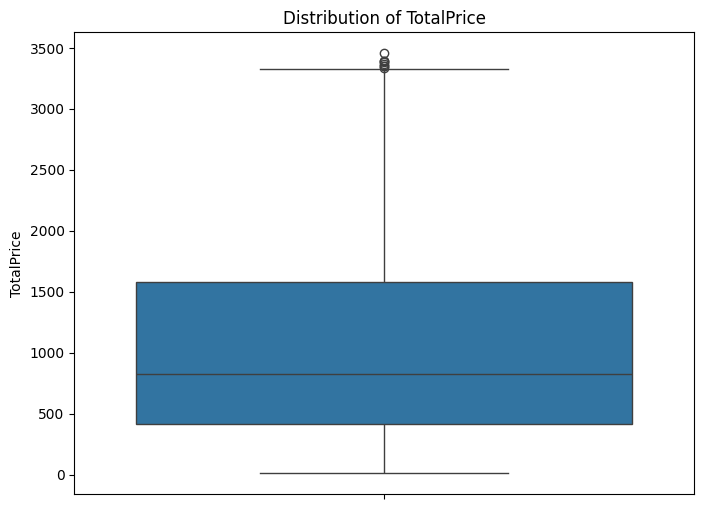

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['TotalPrice'])
plt.title('Distribution of TotalPrice')
plt.ylabel('TotalPrice')
plt.show()

In [ ]:
iqr_outliers_count = df['outlier'].sum()
zscore_outliers_count = df['outlier_z'].sum()
both_outliers_count = df[df['outlier'] & df['outlier_z']].shape[0]

print(f"Number of outliers detected by IQR method: {iqr_outliers_count}")
print(f"Number of outliers detected by Z-score method: {zscore_outliers_count}")
print(f"Number of outliers detected by both methods: {both_outliers_count}")

Number of outliers detected by IQR method: 8
Number of outliers detected by Z-score method: 0
Number of outliers detected by both methods: 0


In [12]:
# Remove outliers identified by the IQR method
df_no_iqr_outliers = df[~df['outlier']]

print("Shape of DataFrame before removing IQR outliers:", df.shape)
print("Shape of DataFrame after removing IQR outliers:", df_no_iqr_outliers.shape)
display(df_no_iqr_outliers.head())

Shape of DataFrame before removing IQR outliers: (1200, 18)
Shape of DataFrame after removing IQR outliers: (1192, 18)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,rolling_mean,outlier,zscore,outlier_z
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,NaN,False,2.194447,False
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,NaN,False,-0.916341,False
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1969.733333,False,2.072840,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1109.763333,False,-0.952335,False
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1843.543333,False,1.768690,False


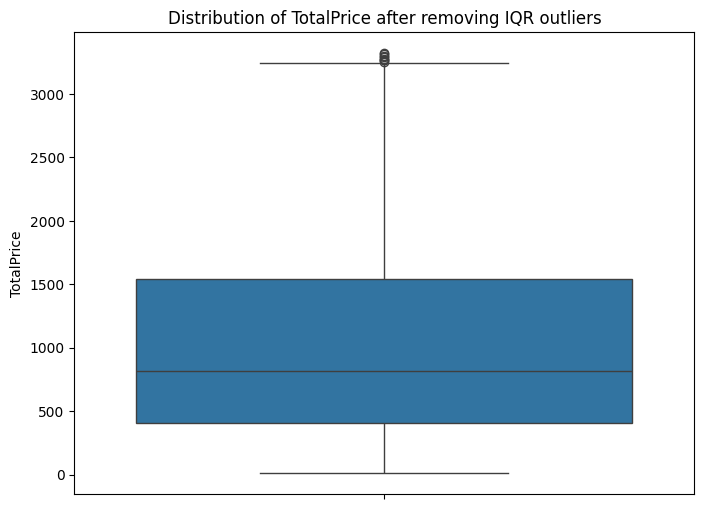

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_no_iqr_outliers['TotalPrice'])
plt.title('Distribution of TotalPrice after removing IQR outliers')
plt.ylabel('TotalPrice')
plt.show()

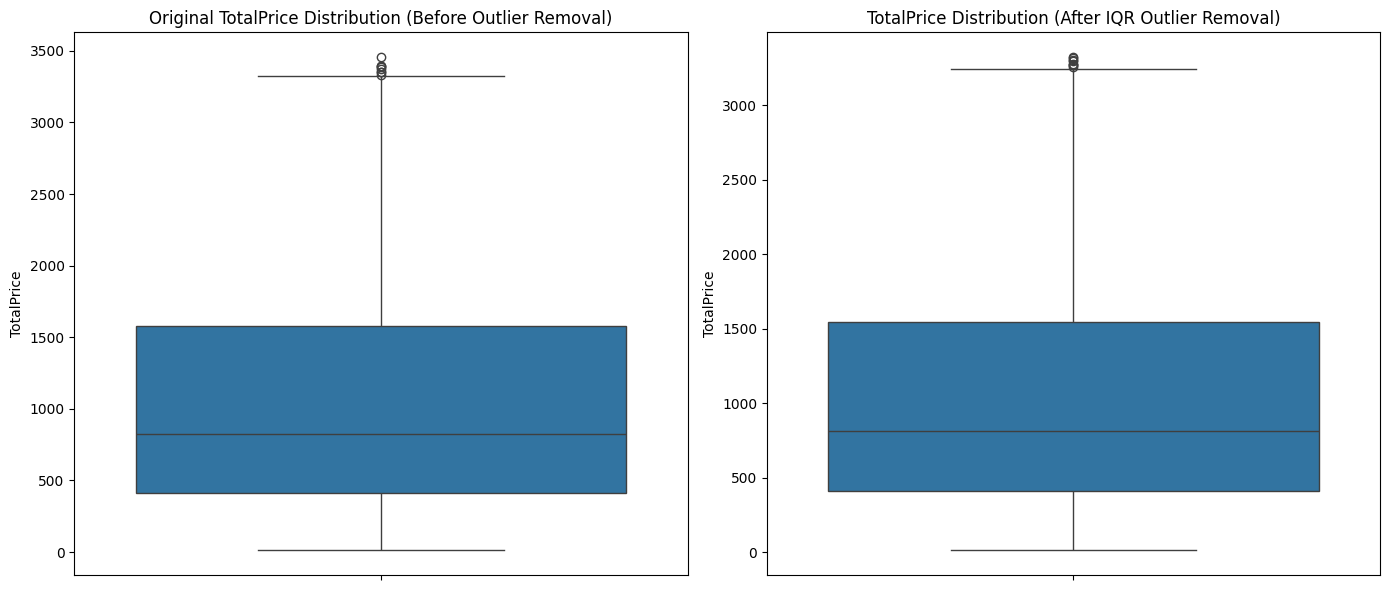

In [14]:
plt.figure(figsize=(14, 6))

# Subplot 1: Original TotalPrice distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df['TotalPrice'])
plt.title('Original TotalPrice Distribution (Before Outlier Removal)')
plt.ylabel('TotalPrice')

# Subplot 2: TotalPrice distribution after removing IQR outliers
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df_no_iqr_outliers['TotalPrice'])
plt.title('TotalPrice Distribution (After IQR Outlier Removal)')
plt.ylabel('TotalPrice')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [15]:
print("Descriptive statistics for df_no_iqr_outliers:")
display(df_no_iqr_outliers.describe())

Descriptive statistics for df_no_iqr_outliers:


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,rolling_mean,zscore
count,1192,1192.000000,1192.000000,1192.000000,1192.000000,1190.000000,1192.000000
mean,2024-03-24 04:08:51.543624192,2.932047,354.268977,5.473993,1038.362886,1048.466989,-0.019034
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,100.190000,-1.271659
25%,2023-08-04 18:00:00,2.000000,185.200000,4.000000,408.890000,674.533333,-0.786818
50%,2024-03-25 00:00:00,3.000000,362.300000,5.000000,816.110000,1014.240000,-0.290122
75%,2024-11-10 00:00:00,4.000000,518.042500,7.000000,1544.490000,1359.460833,0.598302
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3322.550000,2913.976667,2.767047
std,NaN,1.402138,196.085968,2.282190,800.069705,478.411343,0.975865


In [16]:
# Calculate mean and median for the original DataFrame
original_mean_totalprice = df['TotalPrice'].mean()
original_median_totalprice = df['TotalPrice'].median()

# Calculate mean and median for the DataFrame after outlier removal
cleaned_mean_totalprice = df_no_iqr_outliers['TotalPrice'].mean()
cleaned_median_totalprice = df_no_iqr_outliers['TotalPrice'].median()

# Calculate the differences
mean_difference = original_mean_totalprice - cleaned_mean_totalprice
median_difference = original_median_totalprice - cleaned_median_totalprice

print(f"Original TotalPrice Mean: {original_mean_totalprice:.2f}")
print(f"Cleaned TotalPrice Mean: {cleaned_mean_totalprice:.2f}")
print(f"Difference in Mean TotalPrice (Original - Cleaned): {mean_difference:.2f}")
print("\n")
print(f"Original TotalPrice Median: {original_median_totalprice:.2f}")
print(f"Cleaned TotalPrice Median: {cleaned_median_totalprice:.2f}")
print(f"Difference in Median TotalPrice (Original - Cleaned): {median_difference:.2f}")

Original TotalPrice Mean: 1053.97
Cleaned TotalPrice Mean: 1038.36
Difference in Mean TotalPrice (Original - Cleaned): 15.61


Original TotalPrice Median: 823.62
Cleaned TotalPrice Median: 816.11
Difference in Median TotalPrice (Original - Cleaned): 7.50


In [17]:
cleaned_mode_totalprice = df_no_iqr_outliers['TotalPrice'].mode()[0] # .mode() can return multiple modes, so take the first
original_mode_totalprice = df['TotalPrice'].mode()[0] # Get the mode from the original DataFrame

print(f"Original TotalPrice Mode: {original_mode_totalprice}")
print(f"Cleaned TotalPrice Mode: {cleaned_mode_totalprice}")
print(f"Difference in Mode TotalPrice (Original - Cleaned): {original_mode_totalprice - cleaned_mode_totalprice}")

Original TotalPrice Mode: 211.14
Cleaned TotalPrice Mode: 211.14
Difference in Mode TotalPrice (Original - Cleaned): 0.0


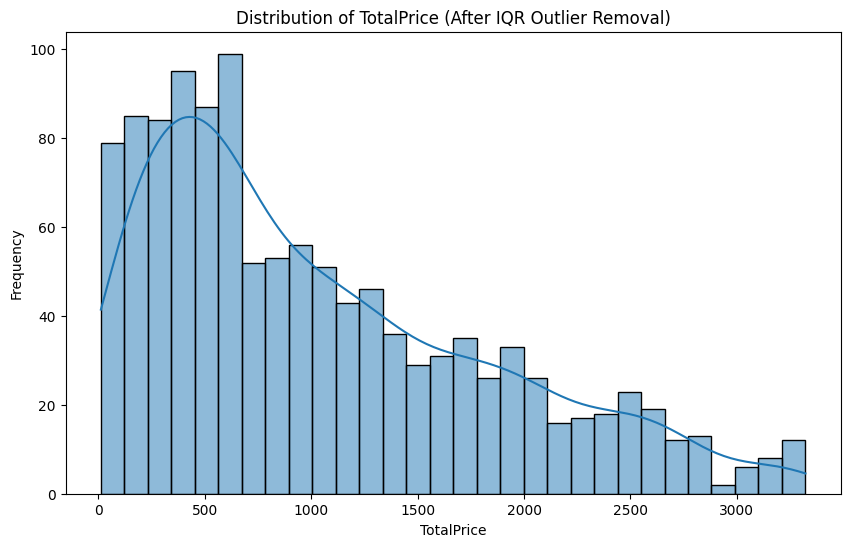

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df_no_iqr_outliers['TotalPrice'], bins=30, kde=True)
plt.title('Distribution of TotalPrice (After IQR Outlier Removal)')
plt.xlabel('TotalPrice')
plt.ylabel('Frequency')
plt.show()
#The distribution is postively skewed

In [19]:
# Select only numerical columns for correlation analysis
numerical_df = df_no_iqr_outliers.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix for Numerical Columns (After IQR Outlier Removal):")
display(correlation_matrix)

Correlation Matrix for Numerical Columns (After IQR Outlier Removal):


,Quantity,UnitPrice,ItemsInCart,TotalPrice,rolling_mean,zscore
Quantity,1.000000,-0.001348,0.649778,0.608364,0.375805,0.608364
UnitPrice,-0.001348,1.000000,-0.007404,0.711844,0.392275,0.711844
ItemsInCart,0.649778,-0.007404,1.000000,0.390672,0.226014,0.390672
TotalPrice,0.608364,0.711844,0.390672,1.000000,0.578230,1.000000
rolling_mean,0.375805,0.392275,0.226014,0.578230,1.000000,0.578230
zscore,0.608364,0.711844,0.390672,1.000000,0.578230,1.000000


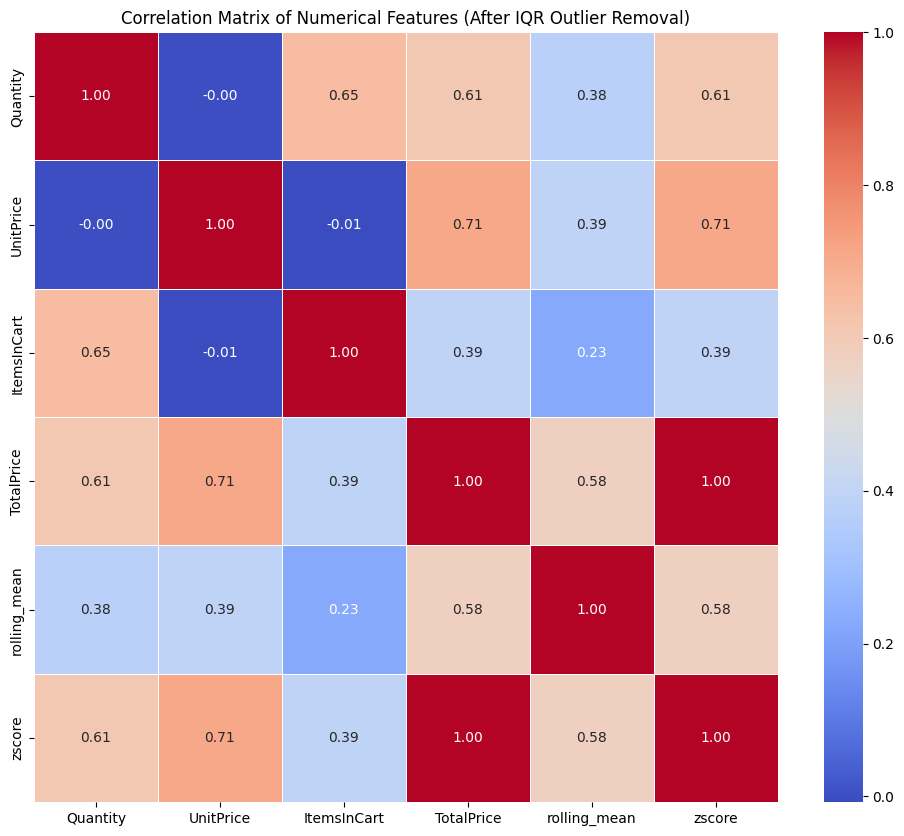

In [21]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (After IQR Outlier Removal)')
plt.show()
